In [28]:
import networkx as nx
from spidercat.draw import draw_spanning_forest_solution
from spidercat.spanning_tree import find_min_height_roots, match_forest_leaves_to_marked_edges
from spidercat.utils import load_solution_triplet
from spidercat.mdsf import constrained_mdsf_generation
from spidercat.circuit_extraction import expand_graph_and_forest, find_mdst

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Absolute Center: 0
M: {(0, 1): 1, (0, 4): 1, (0, 5): 1, (1, 2): 1, (2, 3): 1, (2, 7): 1, (3, 8): 1, (4, 9): 1, (5, 8): 1, (6, 8): 1, (6, 9): 1, (7, 9): 1, (1, 6): 0, (3, 4): 0, (5, 7): 0}
Matchings: {2: [(2, 7)], 3: [(2, 3)], 6: [(6, 8)], 7: [(7, 9)], 8: [(3, 8)], 9: [(6, 9)]}


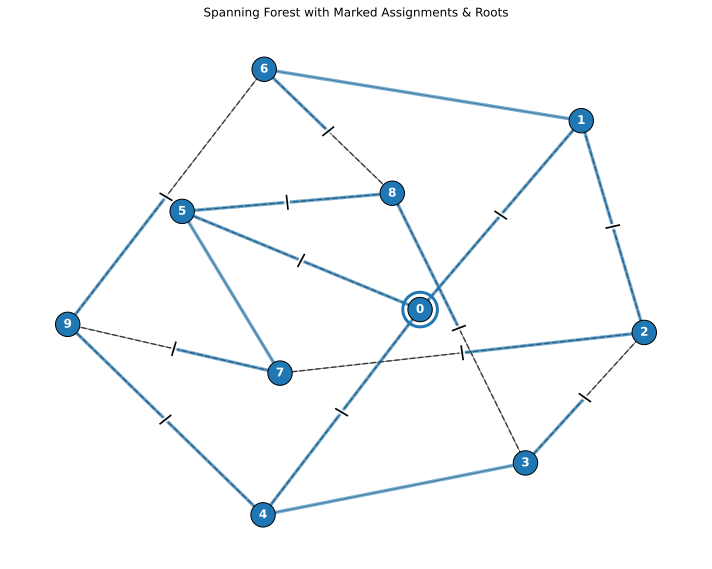

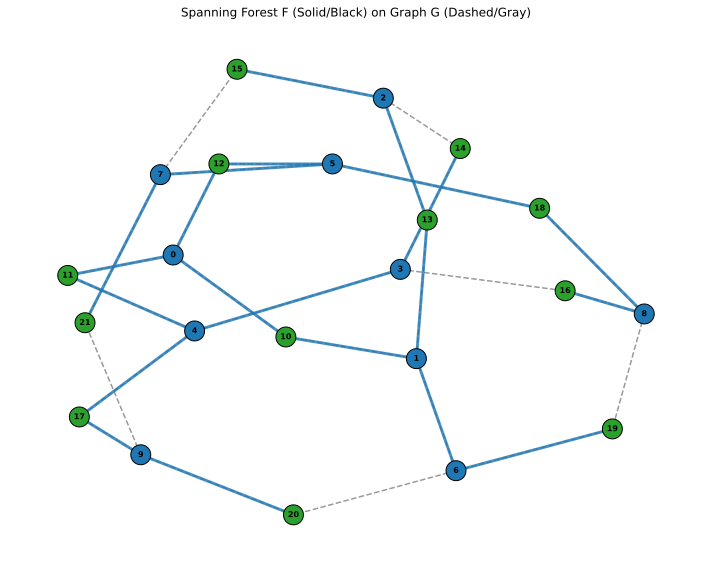

In [51]:
from spidercat.draw import draw_forest_on_graph

N, t = 12, 4
grf, _, M, _ = load_solution_triplet(N, t, 1)
tree, center, radius = find_mdst(grf)
print(f"Absolute Center: {center}")

matchings = match_forest_leaves_to_marked_edges(grf, tree, M)
print(f"M: {M}")
print(f"Matchings: {matchings}")
draw_spanning_forest_solution(grf, tree, M, matchings, {0: center[0] if isinstance(center, tuple) else center}, figsize=(10, 8))
G, F = expand_graph_and_forest(grf, tree, M, matchings)

draw_forest_on_graph(G, F)


--- Starting Pipeline for k=1 ---
Step 1: Running greedy heuristic for initial state...
Initial Greedy Forest Max Diameter: 11
Step 2: Extracting the matching constraint...
Extracted 6 removed edges.
Step 3: Running Simulated Annealing to optimize...
Optimization finished in 1838 steps. Best Diameter: 10


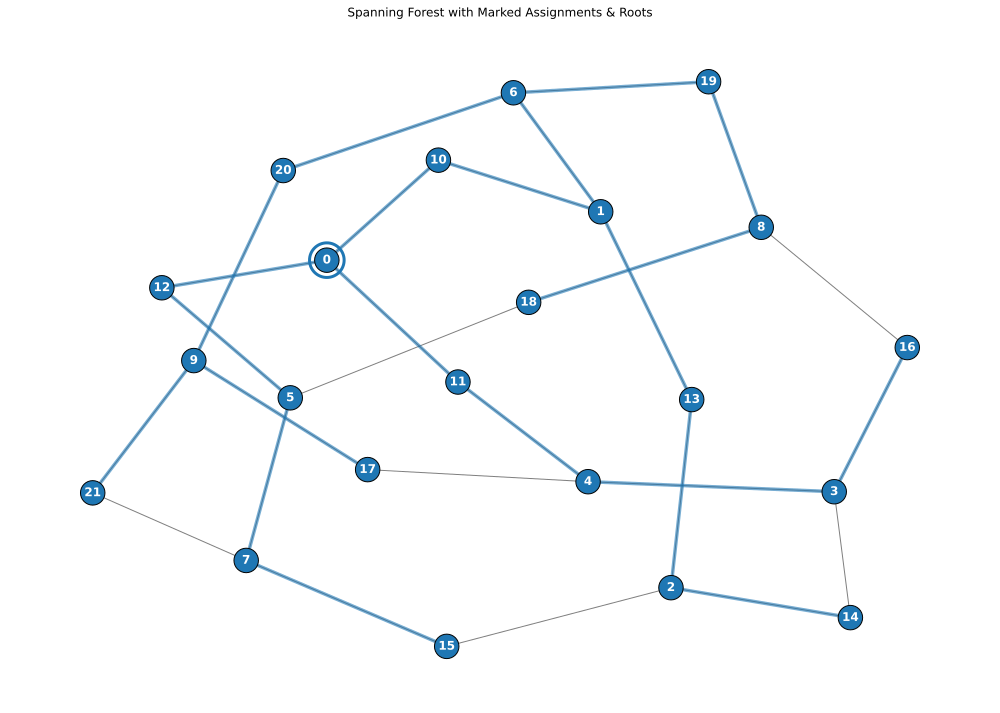

In [52]:
from spidercat.spanning_tree import find_min_height_degree_3_roots

G_alt, _ = expand_graph_and_forest(grf, tree, M, matchings, expand_flags=False)
F_alt = constrained_mdsf_generation(G_alt, 1)
roots = find_min_height_degree_3_roots(F_alt)
draw_spanning_forest_solution(G_alt, F_alt, {}, {}, roots)

=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
  Node 0 -> Branch 10: Spawned CNOT Q0 -> Q1
  Node 0 -> Branch 12: Spawned CNOT Q0 -> Q2
  Node 0 -> Primary 11 (Inherits Q0)
  Mark on 10: Spawned CNOT Q1 -> Q3
  Node 10 -> Primary 1 (Inherits Q1)
  Mark on 12: Spawned CNOT Q2 -> Q4
  Node 12 -> Primary 5 (Inherits Q2)
  Mark on 11: Spawned CNOT Q0 -> Q5
  Node 11 -> Primary 4 (Inherits Q0)
  Node 1 -> Branch 6: Spawned CNOT Q1 -> Q6
  Node 1 -> Primary 13 (Inherits Q1)
  New flag initialised (5, 18): CNOT Q2 -> Q12
  Node 5 -> Primary 7 (Inherits Q2)
  New flag initialised (4, 17): CNOT Q0 -> Q13
  Node 4 -> Primary 3 (Inherits Q0)
  Node 6 -> Branch 19: Spawned CNOT Q6 -> Q7
  Node 6 -> Primary 20 (Inherits Q6)
  Mark on 13: Spawned CNOT Q1 -> Q8
  Node 13 -> Primary 2 (Inherits Q1)
  New flag initialised (7, 21): CNOT Q2 -> Q14
  Node 7 -> Primary 15 (Inherits Q2)
  New flag initialised (3, 14): CNOT Q0 -> Q15
  Node 3 -> Primary 16 (Inherits Q0)
  Mark on 19: S

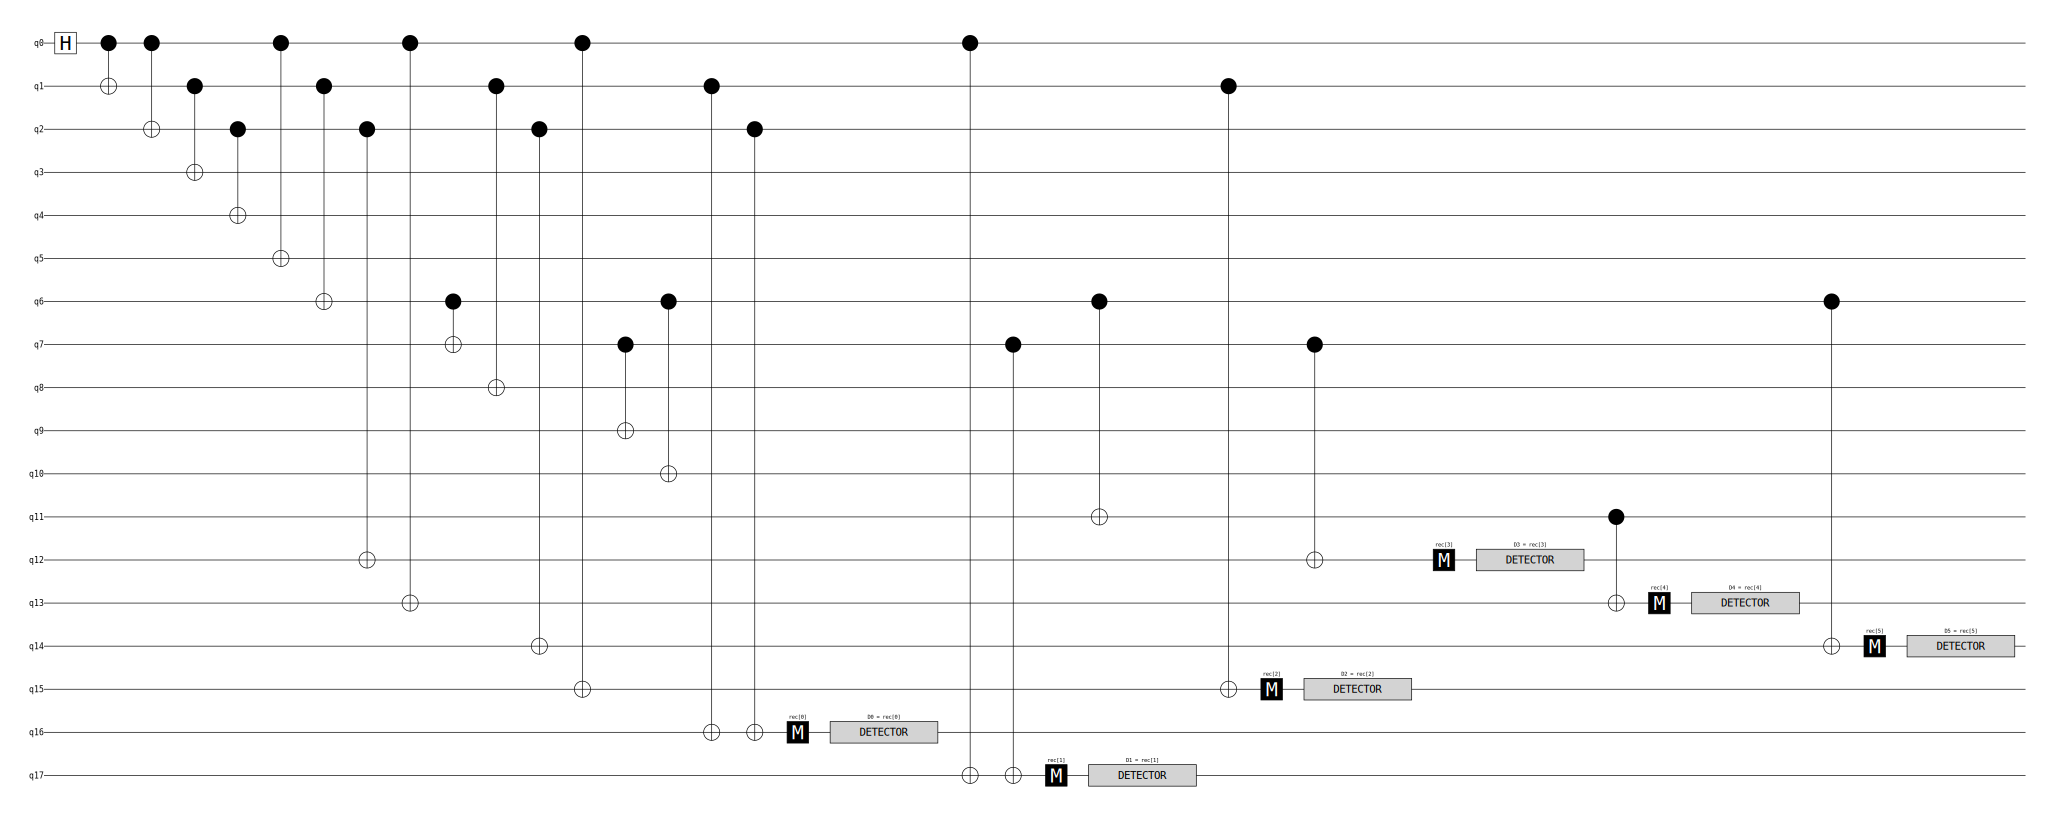

In [53]:
from spidercat.circuit_extraction import extract_from_expanded_graph

circ = extract_from_expanded_graph(G_alt, F_alt, roots, verbose=True)
circ.diagram('timeline-svg')

In [54]:
circ.append("M", range(N))
circ.compile_sampler().sample(10)[:,-N:]

array([[ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True,  True],
       [False, False, False, False, False, False, False, False, False,
        False, False

<Figure size 1000x800 with 0 Axes>

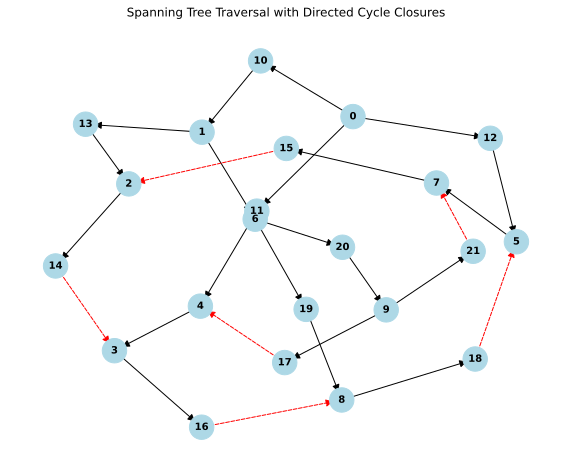

In [55]:
from spidercat.circuit_extraction import build_traversal_digraph
from spidercat.draw import display_digraph


D = build_traversal_digraph(G_alt, F_alt, roots[0])
display_digraph(D)

(15, 2)


<Figure size 1000x800 with 0 Axes>

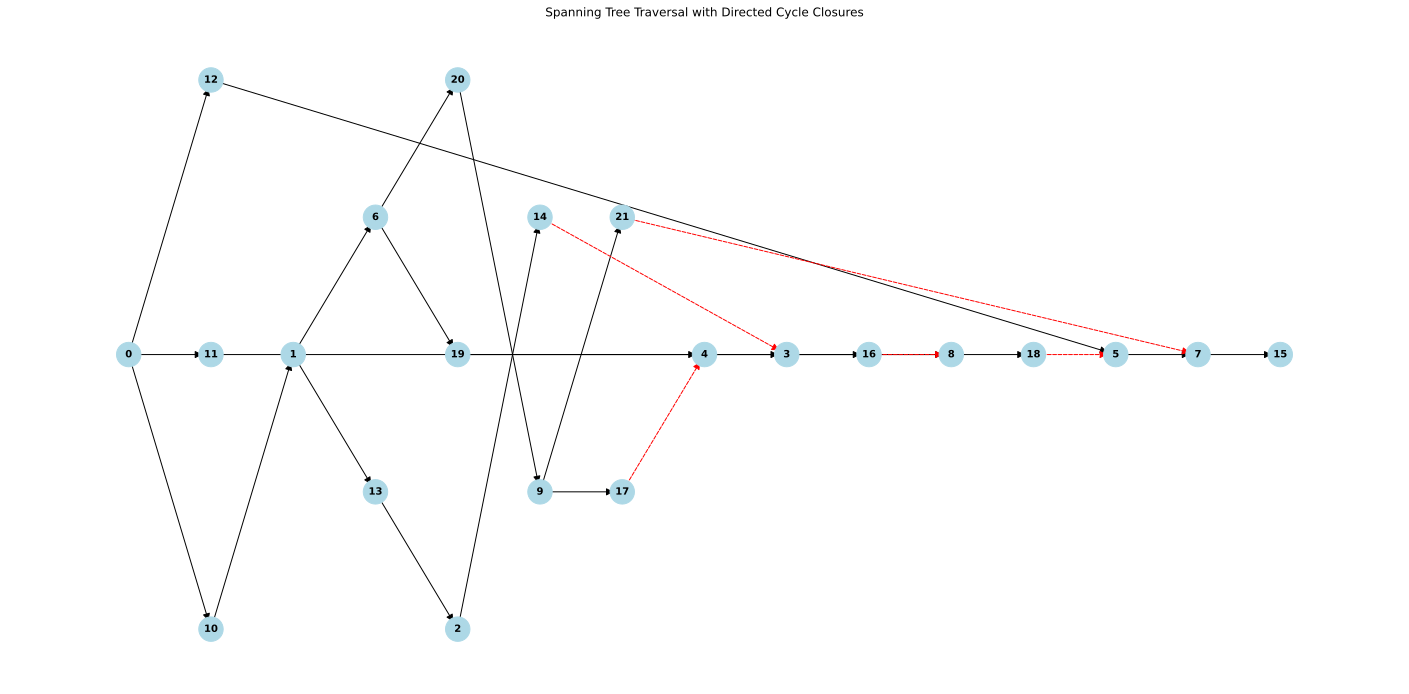

In [56]:
from spidercat.circuit_extraction import resolve_dag_by_removing_missing_link
import networkx as nx


_, edge, dependency_graph = resolve_dag_by_removing_missing_link(D)
print(edge[0])
display_digraph(dependency_graph)

=== Starting Elegant Extraction (BFS) ===
Init Root 0 (Tree 0) -> Q0
  Node 0 -> Branch 10: Spawned CNOT Q0 -> Q1
  Node 0 -> Branch 12: Spawned CNOT Q0 -> Q2
  Node 0 -> Primary 11 (Inherits Q0)
  Mark on 10: Spawned CNOT Q1 -> Q3
  Node 10 -> Primary 1 (Inherits Q1)
  Mark on 12: Spawned CNOT Q2 -> Q4
  Node 12 -> Primary 5 (Inherits Q2)
  Mark on 11: Spawned CNOT Q0 -> Q5
  Node 11 -> Primary 4 (Inherits Q0)
  Node 1 -> Branch 6: Spawned CNOT Q1 -> Q6
  Node 1 -> Primary 13 (Inherits Q1)
  Node 6 -> Branch 19: Spawned CNOT Q6 -> Q7
  Node 6 -> Primary 20 (Inherits Q6)
  Mark on 13: Spawned CNOT Q1 -> Q8
  Node 13 -> Primary 2 (Inherits Q1)
  Mark on 19: Spawned CNOT Q7 -> Q9
  Node 19 -> Primary 8 (Inherits Q7)
  Mark on 20: Spawned CNOT Q6 -> Q10
  Node 20 -> Primary 9 (Inherits Q6)
  New flag initialised (2, 15): CNOT Q1 -> Q12
  Node 2 -> Primary 14 (Inherits Q1)
  Node 9 -> Branch 17: Spawned CNOT Q6 -> Q11
  Node 9 -> Primary 21 (Inherits Q6)
  New flag initialised (14, 3): CNO

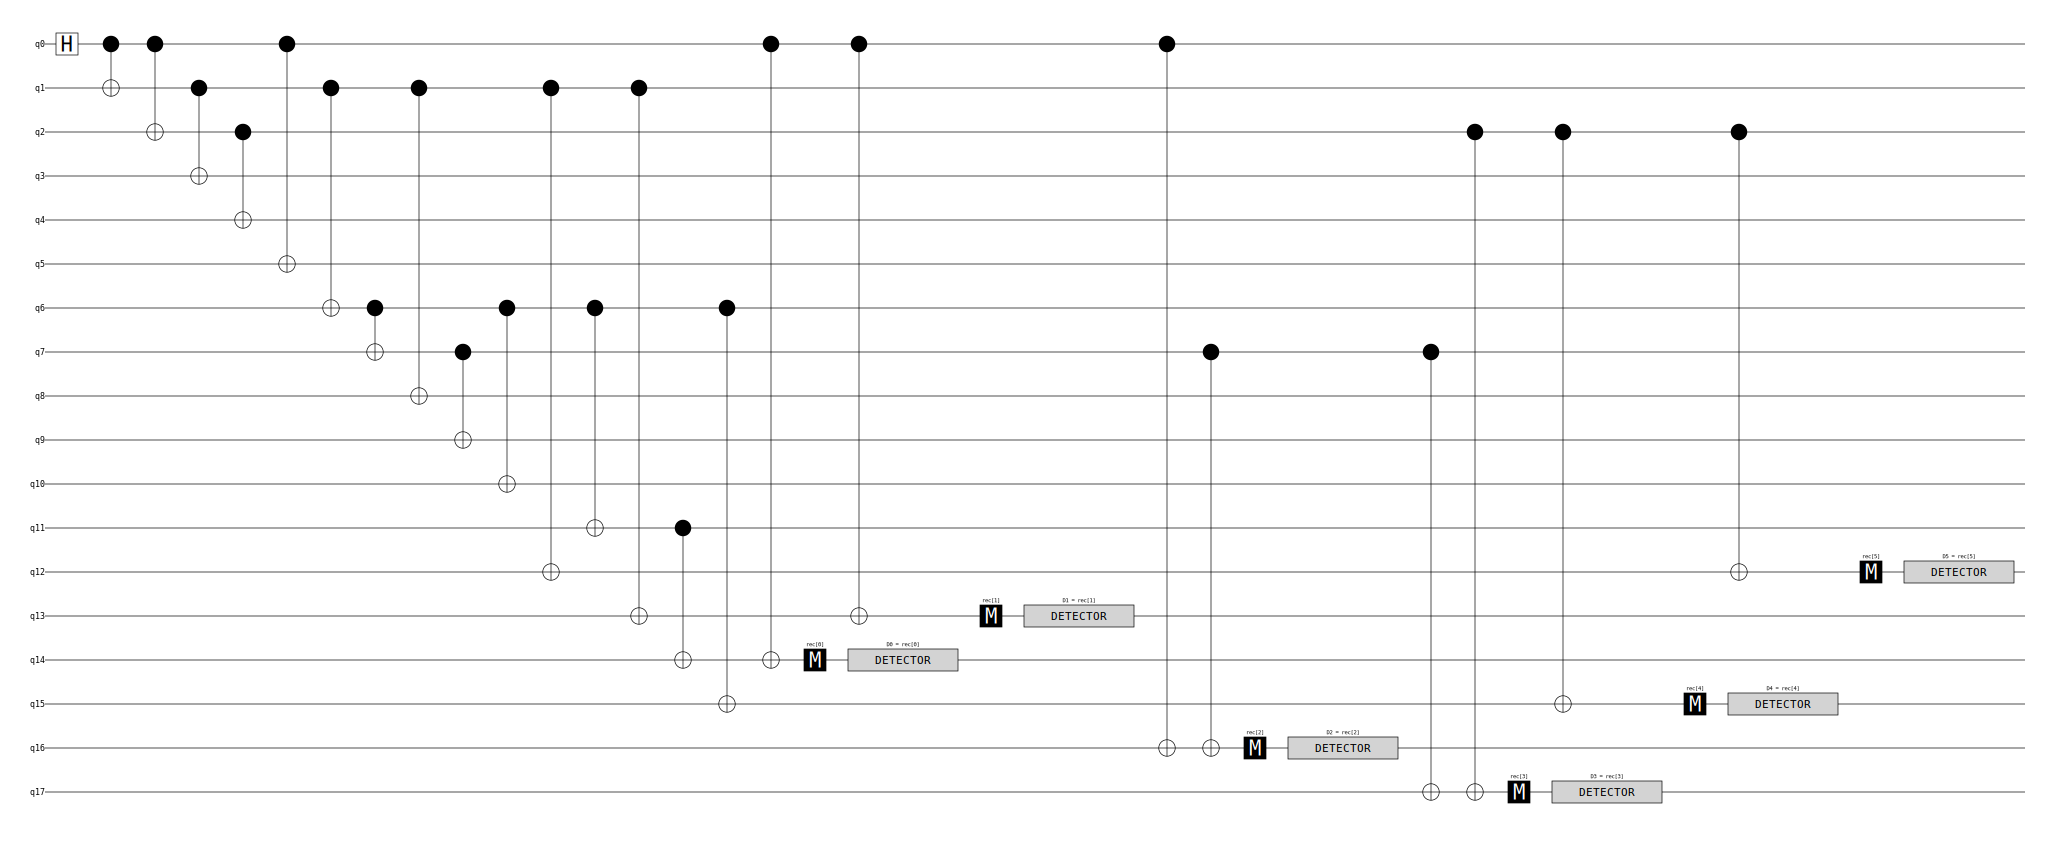

In [57]:
circ = extract_from_expanded_graph(G_alt, F_alt, roots, dependency_graph, verbose=True)
circ.diagram('timeline-svg')